# **Import Library & Data**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv('../dataset-generation/cryst-unnormalized-5000ep-ppo-default-500.csv')
df2 = pd.read_csv('../dataset-generation/cryst-unnormalized-5000ep-ppo-default-30000.csv')
df3 = pd.read_csv('../dataset-generation/cryst-unnormalized-5000ep-random.csv')
print(df1.head(20))
print('-'*50)
print(df2.head(20))
print('-'*50)
print(df3.head(20))
print('-'*50)
print(df1.shape, df2.shape, df3.shape)

            mu0            mu1          mu2         C        CV         Ln  \
0   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
1   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
2   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
3   1500.000000   23000.000000   1800000.00  0.160000  1.000000  15.000000   
4   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
5   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
6   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
7   1753.685913   48816.582031   3005200.25  0.159571  0.074865  27.503227   
8   2206.455078   80213.414062   5138588.00  0.158856 -0.152808  36.020634   
9   2206.462402   80213.578125   5138600.50  0.158856 -0.152807  36.020599   
10  2206.467529   80213.687500   5138607.50  0.158856 -0.152806  36.020573   
11  2206.447510   80213.140625   5138570.50  0.158856 -0.152808 

In [ ]:
df = pd.concat([df1, df2,df3], axis=0)
df

,mu0,mu1,mu2,C,CV,Ln,CV_SP,Ln_SP,mu3
0,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
1,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
2,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
3,1500.000000,2.300000e+04,1.800000e+06,0.160000,1.000000,15.000000,1.0,15.0,2.500000e+08
4,1753.685913,4.881658e+04,3.005200e+06,0.159571,0.074865,27.503227,1.0,15.0,3.790643e+08
...,...,...,...,...,...,...,...,...,...
144995,336200.375000,5.059848e+06,2.459005e+08,0.081437,0.467194,14.716766,1.0,15.0,2.386137e+10
144996,347912.031250,5.142655e+06,2.469948e+08,0.080832,0.473923,14.448122,1.0,15.0,2.404313e+10
144997,349708.437500,5.175920e+06,2.474738e+08,0.080846,0.467637,14.467314,1.0,15.0,2.403895e+10
144998,344554.187500,5.065091e+06,2.451176e+08,0.081125,0.488102,14.367105,1.0,15.0,2.395515e+10


In [26]:
df.describe()

,mu0,mu1,mu2,C,CV,Ln,CV_SP,Ln_SP,mu3
count,435000.000000,4.350000e+05,4.350000e+05,435000.000000,435000.000000,435000.000000,435000.0,435000.0,4.350000e+05
mean,150477.551029,2.640969e+06,1.383502e+08,0.114196,0.274025,22.565072,1.0,15.0,1.401595e+10
std,124318.060625,1.892845e+06,9.100794e+07,0.029368,0.224115,7.797074,0.0,0.0,8.826196e+09
min,1500.000000,2.300000e+04,1.800000e+06,0.080140,-0.176087,14.135282,1.0,15.0,2.500000e+08
25%,18497.683594,5.657038e+05,4.099245e+07,0.086787,0.173863,15.961856,1.0,15.0,4.760145e+09
50%,141452.781250,2.953382e+06,1.648912e+08,0.103676,0.286172,19.739491,1.0,15.0,1.717768e+10
75%,269682.468750,4.494904e+06,2.251398e+08,0.144993,0.405137,27.524300,1.0,15.0,2.225344e+10
max,355471.875000,5.260476e+06,2.508301e+08,0.160000,1.000000,40.058300,1.0,15.0,2.425106e+10


# **MinMaxScaler**

# **Data Processing**

In [27]:
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns=['mu3', 'CV_SP', 'Ln_SP'])
y = df[['mu3']]

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y_scaled = pd.DataFrame(y_scaled, columns=y.columns, index=y.index)

In [28]:
X_scaled.columns

Index(['mu0', 'mu1', 'mu2', 'C', 'CV', 'Ln'], dtype='str')

In [ ]:
# Windowing the dataset
for i in X_scaled.columns:
    for t in range(1,6):
        X_scaled[f'{i}_{t}'] = X_scaled[i].shift(t)

print(X_scaled.shape)
print('-'*50)
print(X_scaled)

(435000, 36)
--------------------------------------------------
             mu0       mu1       mu2         C        CV        Ln     mu0_1  \
0       0.000000  0.000000  0.000000  1.000000  1.000000  0.033357       NaN   
1       0.000000  0.000000  0.000000  1.000000  1.000000  0.033357  0.000000   
2       0.000000  0.000000  0.000000  1.000000  1.000000  0.033357  0.000000   
3       0.000000  0.000000  0.000000  1.000000  1.000000  0.033357  0.000000   
4       0.000717  0.004929  0.004840  0.994623  0.213379  0.515679  0.000000   
...          ...       ...       ...       ...       ...       ...       ...   
144995  0.945556  0.961694  0.980205  0.016237  0.546967  0.022431  0.941232   
144996  0.978643  0.977504  0.984599  0.008665  0.552688  0.012068  0.945556   
144997  0.983718  0.983856  0.986523  0.008839  0.547344  0.012808  0.978643   
144998  0.969157  0.962695  0.977061  0.012330  0.564745  0.008943  0.983718   
144999  0.971064  0.971551  0.986688  0.011023  0.558703

In [ ]:
# 1. Group columns explicitly by their historical lag (Timesteps)
# We want 6 timesteps: from oldest (lag 5) to current (no lag)
time_ordered_groups = [
    ['mu0_5', 'mu1_5', 'mu2_5', 'CV_5', 'Ln_5'], # Step t-5 (Oldest)
    ['mu0_4', 'mu1_4', 'mu2_4', 'CV_4', 'Ln_4'], # Step t-4
    ['mu0_3', 'mu1_3', 'mu2_3', 'CV_3', 'Ln_3'], # Step t-3
    ['mu0_2', 'mu1_2', 'mu2_2', 'CV_2', 'Ln_2'], # Step t-2
    ['mu0_1', 'mu1_1', 'mu2_1', 'CV_1', 'Ln_1'], # Step t-1
    ['mu0',   'mu1',   'mu2',   'CV',   'Ln']    # Step t   (Current)
]

# 2. Re-order your Dataframe columns horizontally to match this chronological block pattern
flat_ordered_columns = [col for step in time_ordered_groups for col in step]
X_scaled = X_scaled[flat_ordered_columns]

print(X_scaled.columns)

Index(['mu0_5', 'mu1_5', 'mu2_5', 'C_5', 'CV_5', 'Ln_5', 'mu0_4', 'mu1_4',
       'mu2_4', 'C_4', 'CV_4', 'Ln_4', 'mu0_3', 'mu1_3', 'mu2_3', 'C_3',
       'CV_3', 'Ln_3', 'mu0_2', 'mu1_2', 'mu2_2', 'C_2', 'CV_2', 'Ln_2',
       'mu0_1', 'mu1_1', 'mu2_1', 'C_1', 'CV_1', 'Ln_1', 'mu0', 'mu1', 'mu2',
       'C', 'CV', 'Ln'],
      dtype='str')


In [31]:
X_scaled.dropna(inplace=True)
y_scaled = y_scaled.tail(-5)
print(X_scaled.shape, y_scaled.shape)

(434995, 36) (434995, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y_scaled,test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(326246, 36) (108749, 36) (326246, 1) (108749, 1)


In [33]:
import xgboost as xgb
import joblib

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
# joblib.dump(xgb_model, "xgb_model.pkl")
xgb_model.save_model("xgb_window.json")

In [35]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred = xgb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_pred=y_pred, y_true=y_test)
print(f"RMSE: {rmse}")
print(f'R2: {r2}')

RMSE: 0.0005892340559512377
R2: 0.9999974370002747


In [12]:
import subprocess

# Runs the script exactly like a command prompt/terminal command
subprocess.run(["python", "../noti/playsound.py"])

/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.12.10)
Hello from the pygame community. https://www.pygame.org/contribute.html


CompletedProcess(args=['python', '../noti/playsound.py'], returncode=0)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import uniform, randint

# 2. Define Model and Search Space
xgb_model = xgb.XGBRegressor()
param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5)
}

# 3. Configure Randomized Search
search = RandomizedSearchCV(xgb_model, param_dist, n_iter=100, cv=5, n_jobs=-1)

# 4. Fit and Evaluate
search.fit(X_train, y_train)
print("Best Params:", search.best_params_)
print("Best Score:", search.best_score_)

from sklearn.metrics import root_mean_squared_error

y_pred = search.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
search.best_estimator_.save_model("xgb_window_opt.json")
print('Model is saved successfully!')

Best Params: {'colsample_bytree': np.float64(0.7727222431834659), 'learning_rate': np.float64(0.06458339758367941), 'max_depth': 9, 'n_estimators': 272, 'subsample': np.float64(0.6293835941756447)}
Best Score: 0.9999980688095093
RMSE: 0.00047486036783084273


<Axes: title={'center': 'Feature Importance(Cover)'}, xlabel='Importance score', ylabel='Features'>

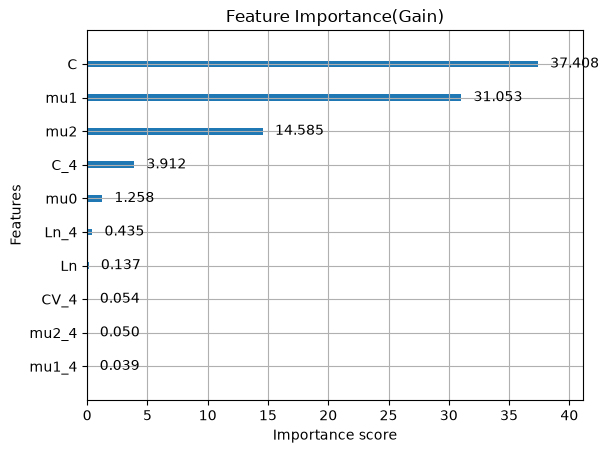

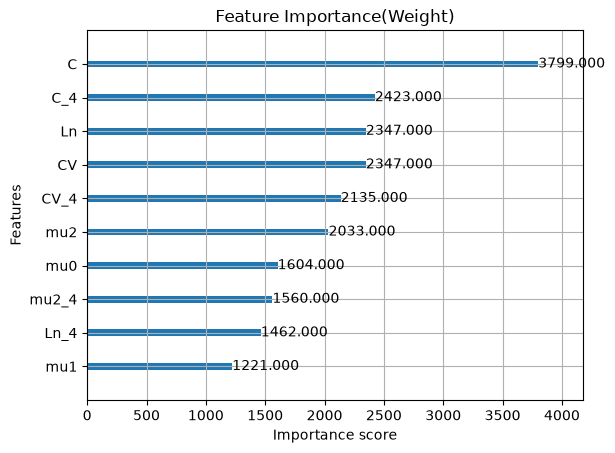

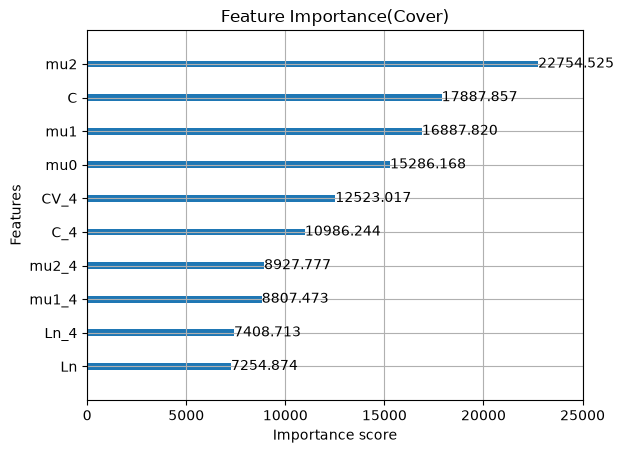

In [22]:
from xgboost import plot_importance

plot_importance(search.best_estimator_, importance_type='gain', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Gain)') # Or weight, cover
plot_importance(search.best_estimator_, importance_type='weight', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Weight)') # Or weight, cover
plot_importance(search.best_estimator_, importance_type='cover', max_num_features=10, values_format="{v:.3f}", title='Feature Importance(Cover)') # Or weight, cover

In [16]:
import pandas as pd

# Get importance scores
importances = search.best_estimator_.feature_importances_

# Create a DataFrame for better readability
feat_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)
